Analyze results from the pathway enrichment across all conditions and -omes

## Setup

### Imports

In [1]:
import os
from typing import Optional, Literal

import polars as pl
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt, rcParams, colors, cm

# set max font size 
rcParams["font.size"] = 7

### Constants

In [3]:
# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "pathway_enrichment"
)

# directory for differentially expressed features
RESULTS_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache",
    "pathway_enrichment"
)

### Load Data

#### Helper Function: load all pathway enrichment results from specified comparison

In [3]:
def load_pathway_results(
    subset_id: str,
    direction: str
) -> Optional[pl.DataFrame] :
    # gather all of the results from the different databases and
    # sources of differentially expressed proteins
    all_results = [
        (
            pl.read_csv(results_f)
            .with_columns(
                (
                    pl.lit(block)
                    .alias("block")
                ),
                (
                    pl.concat_str(
                        pl.lit(f"[{db[0].upper()}]"),
                        pl.col("pathway_name"),
                        separator=" "
                    )
                    .alias("pathway_name")
                )
            )
            .select(
                "pathway_name",
                "block",
                "gene_count",
                "p_adjust",
                "gene_symbols",
                "pathway_genes"
            )
            .sort("p_adjust")
            .head(5)
        )
        for db in ["hallmark", "kegg", "reactome"]
        for block in ["Transcriptomics", "Proteomics", "Lipid-Protein-Associations"]
        if os.path.isfile(results_f := os.path.join(   
                RESULTS_DIR,
                f"{db}/{subset_id}_{block}_{direction}.csv"
        ))
    ]
    if all_results:
        # filter the resulting pathways to remove any duplicate entries
        return (
            pl.concat(all_results)
            .sort(
                "p_adjust",
            )
            .group_by(
                "pathway_name",
                "block",
            )
            .agg(
                pl.col("gene_count").first(),
                pl.col("p_adjust").first(),
                pl.col("gene_symbols").first(),
                pl.col("pathway_genes").first()
            )
            .with_row_index()
        )
    # if no results, return None
    return None

#### Pre-load all of the pathway enrichment results

In [4]:
# key: (subset_id, direction)
# value: pathway_results_dataframe
results = {
    (subset_id, direction): r 
    for subset_id in [
        "B_NPM1-WT", "W_NPM1-WT", 
        "B_FLT3-ITD-WT", "W_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT", "W_FLT3-ITDxNPM1-WT"
    ]
    for direction in ["up", "down"]
    if (r := load_pathway_results(subset_id, direction)) is not None
}

#### Dump all of the pathways to a single arrow/CSV table

In [7]:
all_pathways = (
    pl.concat([
        (
           df
           .drop("index")
           .rename({
               "block": "omics_type"
           })
           .with_columns(
               pl.lit({"B": "Black", "W": "White"}[subset_id[0]]).alias("population"),
               pl.lit(subset_id.split("_", 1)[1]).alias("mutation_comparison"),
               pl.lit(direction).alias("direction"),
           )
        )
        for (subset_id, direction), df in results.items()
    ])
)
all_pathways

pathway_name,omics_type,gene_count,p_adjust,gene_symbols,pathway_genes,population,mutation_comparison,direction
str,str,i64,f64,str,str,str,str,str
"""[K] ATP-dependent chromatin re…","""Lipid-Protein-Associations""",7,0.012042,"""SS18/ACTR5/SMARCB1/RBBP7/BRD8/…","""ACTB/ACTG1/ACTL6A/ACTL6B/ACTR5…","""Black""","""NPM1-WT""","""up"""
"""[R] Cilium Assembly""","""Proteomics""",7,0.000523,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACTR1A/AHI1/AKAP9/ALMS1/ARF4/A…","""Black""","""NPM1-WT""","""up"""
"""[R] Intraflagellar transport""","""Proteomics""",6,0.000006,"""IFT140/TTC21B/WDR35/TRAF3IP1/I…","""CLUAP1/DYNC2H1/DYNC2I1/DYNC2I2…","""Black""","""NPM1-WT""","""up"""
"""[R] Hedgehog 'off' state""","""Proteomics""",5,0.001772,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADCY1/ADCY10/ADCY2/ADCY3/ADCY4…","""Black""","""NPM1-WT""","""up"""
"""[R] Organelle biogenesis and m…","""Proteomics""",7,0.003315,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACSS2/ACTR1A/AHI1/AKAP9/ALAS1/…","""Black""","""NPM1-WT""","""up"""
…,…,…,…,…,…,…,…,…
"""[R] Extracellular matrix organ…","""Transcriptomics""",12,0.043472,"""LAMC1/APP/COL17A1/COL8A2/P4HB/…","""A2M/ACAN/ACTA1/ACTA2/ACTB/ACTC…","""White""","""FLT3-ITDxNPM1-WT""","""down"""
"""[R] Diseases associated with t…","""Lipid-Protein-Associations""",5,0.012164,"""TLR4/S100A8/S100A9/MYD88/TLR5""","""BTK/CD14/CD36/CHUK/FGA/FGB/FGG…","""White""","""FLT3-ITDxNPM1-WT""","""down"""
"""[K] Serotonergic synapse""","""Proteomics""",5,0.047539,"""ALOX12/APP/GNG2/GNAI1/ALOX15""","""ADCY5/ALOX12/ALOX12B/ALOX15/AL…","""White""","""FLT3-ITDxNPM1-WT""","""down"""


In [19]:
all_pathways.write_ipc(
    os.path.join(
        RESULTS_DIR,
        "pathways.arrow"
    )
)

In [20]:
all_pathways.write_csv(
    os.path.join(
        RESULTS_DIR,
        "pathways.csv"
    )
)

#### TODO
Automate uploading/updating the all pathways table (apache arrow + csv) to synapse (`syn74802869` and `syn74802870`, respectively). In the meantime, I manually uploaded them.

## Analysis
### Helper Functions

In [8]:
def v2c(
    v: float, 
    vmin: float, 
    vmax: float
) -> str : 
    """
    map a value to a color using the "coolwarm" colormap
    """
    return colors.to_hex(
        cm.ScalarMappable(
            norm=colors.Normalize(vmin=vmin, vmax=vmax), 
            cmap="coolwarm"
        ).to_rgba(v)  # type: ignore
    )

In [9]:
def overlap_factor(genes_a, genes_b):
    sa = set(genes_a.split("/"))
    sb = set(genes_b.split("/"))
    return len(sa & sb) / len(sa | sb)

In [10]:
def build_pathway_graph(
    r,
    min_node_size=5,
    min_overlap_factor=0.05,
    top_n_pathways=10
):
    # initialize graph
    g = nx.Graph()

    # add nodes (pathways, metrics as metadata)
    for i, p, b, n, pv in (
        r
        .select(pl.exclude("gene_symbols", "pathway_genes"))
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .iter_rows()    
    ):
        g.add_node(
            i,
            name=p,
            block=b,
            n=n,
            p_value=pv
        )

    # add edges
    for i, pg_i in (
        r
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .select("index", "pathway_genes")
        .iter_rows()    
    ):
        for j, pg_j in (
            r
            .filter(pl.col("gene_count") >= min_node_size)
            .sort("p_adjust")
            .head(top_n_pathways)
            .select("index", "pathway_genes")
            .iter_rows()    
        ):
            if (
                i != j 
                # only add edges for nodes with at least 10% overlap
                and (overlap := overlap_factor(pg_i, pg_j)) > min_overlap_factor
            ): 
                g.add_edge(
                    i,
                    j,
                    overlap=overlap
                )
    
    return g

In [15]:
def plot_pathway_network(
    g, 
    ax,
    direction: Literal["up", "down"],
    add_labels=True,
    label_rotation=10,
) :

    pos = nx.kamada_kawai_layout(g)

    nx.draw_networkx_edges(
        g, 
        pos, 
        ax=ax, 
        edge_color="#999999",
        width=[
            d["overlap"] * 5
            for *_, d in g.edges(data=True)
        ]
    )

    cmult = 1. if direction == "down" else -1.
    szmult = 1.

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Transcriptomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_shape="^"
    )

    nx.draw_networkx_nodes(
        g, 
        pos, 
        ax=ax, 
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Proteomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_shape="s"
    )

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Lipid-Protein-Associations"],
        node_color=[
            # take the first omics_type="Lipid-Protein-Associations" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_shape="o"
    )

    if add_labels:
        lbls = nx.draw_networkx_labels(
            g, 
            pos,
            {
                n: d["name"]
                for n, d in g.nodes(data=True)
            }, 
            ax=ax,
            font_size=7,
            font_family="Arial",
            horizontalalignment="left",
            verticalalignment="bottom", 
            clip_on=False
        )
        for _, text in lbls.items():
            text.set_verticalalignment("center")
            text.set_rotation_mode("anchor")
            text.set_rotation(label_rotation)

### Plot pathway overview

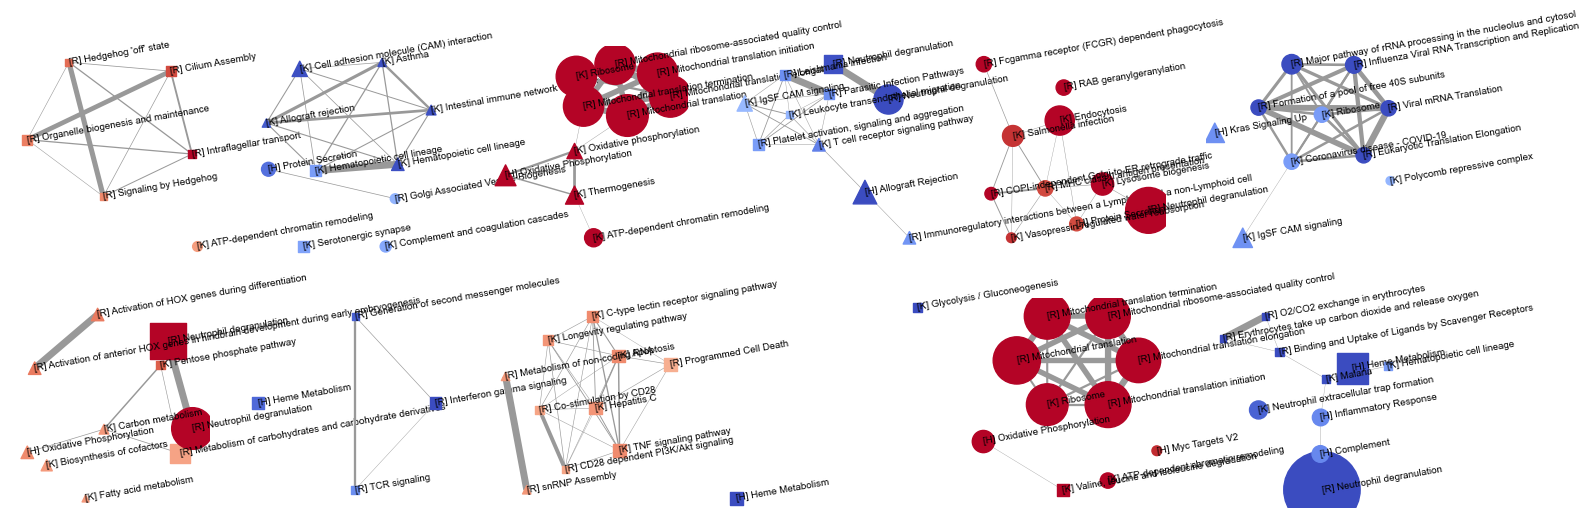

In [16]:
fig, (axs_top, axs_bot) = plt.subplots(
    figsize=(18, 6),
    nrows=2,
    ncols=6
)    

for ax, (subset_id, direction) in zip(axs_top, [(f"B_{m}-WT", d) for m in ["NPM1", "FLT3-ITD", "FLT3-ITDxNPM1"] for d in ["up", "down"]]):
    if (r := results.get((subset_id, direction))) is not None:
        g = build_pathway_graph(r)
        plot_pathway_network(g, ax, direction, add_labels=True)
    ax.set_axis_off()

for ax, (subset_id, direction) in zip(axs_bot, [(f"W_{m}-WT", d) for m in ["NPM1", "FLT3-ITD", "FLT3-ITDxNPM1"] for d in ["up", "down"]]):
    if (r := results.get((subset_id, direction))) is not None:
        g = build_pathway_graph(r)
        plot_pathway_network(g, ax, direction, add_labels=True)
    ax.set_axis_off()

plt.savefig("/Users/dylan.ross/Downloads/out.png", dpi=350, transparent=True)
plt.show()
plt.close()

### Focused analysis of pathways by mutation

In [4]:
all_pathways = pl.read_ipc(
    os.path.join(
        RESULTS_DIR,
        "pathways.arrow"
    )
)
all_pathways

pathway_name,omics_type,gene_count,p_adjust,gene_symbols,pathway_genes,population,mutation_comparison,direction
str,str,i64,f64,str,str,str,str,str
"""[K] ATP-dependent chromatin re…","""Lipid-Protein-Associations""",7,0.012042,"""SS18/ACTR5/SMARCB1/RBBP7/BRD8/…","""ACTB/ACTG1/ACTL6A/ACTL6B/ACTR5…","""Black""","""NPM1-WT""","""up"""
"""[R] Cilium Assembly""","""Proteomics""",7,0.000523,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACTR1A/AHI1/AKAP9/ALMS1/ARF4/A…","""Black""","""NPM1-WT""","""up"""
"""[R] Intraflagellar transport""","""Proteomics""",6,0.000006,"""IFT140/TTC21B/WDR35/TRAF3IP1/I…","""CLUAP1/DYNC2H1/DYNC2I1/DYNC2I2…","""Black""","""NPM1-WT""","""up"""
"""[R] Hedgehog 'off' state""","""Proteomics""",5,0.001772,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADCY1/ADCY10/ADCY2/ADCY3/ADCY4…","""Black""","""NPM1-WT""","""up"""
"""[R] Organelle biogenesis and m…","""Proteomics""",7,0.003315,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACSS2/ACTR1A/AHI1/AKAP9/ALAS1/…","""Black""","""NPM1-WT""","""up"""
…,…,…,…,…,…,…,…,…
"""[R] Extracellular matrix organ…","""Transcriptomics""",12,0.043472,"""LAMC1/APP/COL17A1/COL8A2/P4HB/…","""A2M/ACAN/ACTA1/ACTA2/ACTB/ACTC…","""White""","""FLT3-ITDxNPM1-WT""","""down"""
"""[R] Diseases associated with t…","""Lipid-Protein-Associations""",5,0.012164,"""TLR4/S100A8/S100A9/MYD88/TLR5""","""BTK/CD14/CD36/CHUK/FGA/FGB/FGG…","""White""","""FLT3-ITDxNPM1-WT""","""down"""
"""[K] Serotonergic synapse""","""Proteomics""",5,0.047539,"""ALOX12/APP/GNG2/GNAI1/ALOX15""","""ADCY5/ALOX12/ALOX12B/ALOX15/AL…","""White""","""FLT3-ITDxNPM1-WT""","""down"""


In [24]:
with pl.Config(set_tbl_rows=80, set_fmt_str_lengths=100):
    neutrophil_paths = (
        all_pathways
        .filter(
            (pl.col("mutation_comparison").is_in(["NPM1-WT", "FLT3-ITDxNPM1-WT"]))
            & (pl.col("gene_count") >=5)
            & (pl.col("omics_type").is_in(["Transcriptomics", "Proteomics"]))
            & (
                pl.col("pathway_name")
                .str.contains("Neutrophil")
            )
        )
        .select(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name",
            "gene_symbols", 
            "omics_type"
        )
        .sort(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name"
        )
    )
    display(neutrophil_paths)

mutation_comparison,population,direction,pathway_name,gene_symbols,omics_type
str,str,str,str,str,str
"""FLT3-ITDxNPM1-WT""","""Black""","""down""","""[R] Neutrophil degranulation""","""CLEC5A/SLC44A2/CD55/ORM1/S100P/SLC2A3/FCAR/MGAM/CR1/CXCL1/PIGR/MMP9/C5AR1/PADI2/CD93/CEACAM3/S100A8""","""Transcriptomics"""
"""FLT3-ITDxNPM1-WT""","""White""","""down""","""[R] Neutrophil degranulation""","""CNN2/SLC44A2/GPI/TRPM2/RAB27A/QPCT/CD55/CLEC4D/MPO/ANPEP/BPI/ATP6AP2/CEACAM8/S100P/SLPI/CEACAM6/ARPC…","""Transcriptomics"""
"""NPM1-WT""","""Black""","""down""","""[R] Neutrophil degranulation""","""CD177/CHI3L1/PRG3/CKAP4/SLC44A2/LILRA3/LTF/CAMP/RAB31/S100P/CD14/ANPEP/TMC6/PRTN3/CLEC5A/ALOX5""","""Proteomics"""
"""NPM1-WT""","""White""","""up""","""[R] Neutrophil degranulation""","""PGM1/CAT/HEBP2/MVP/FABP5/NIT2/PTPN6/ATP8B4/PRKCD/CFD/DPP7/CST3/APRT/KCNAB2/PGM2/ATG7/RAB3D/NAPRT/TLR…","""Proteomics"""


In [22]:
for _ in sorted(set(("/".join(neutrophil_paths["gene_symbols"].to_list())).split("/"))):
    print(_)

ALOX5
ANPEP
APRT
ARPC5
ATG7
ATP6AP2
ATP8B4
BPI
C5AR1
CAMP
CAT
CD14
CD177
CD55
CD93
CEACAM3
CEACAM6
CEACAM8
CFD
CHI3L1
CKAP4
CLEC4D
CLEC5A
CNN2
CR1
CST3
CTSZ
CXCL1
DEFA4
DPP7
FABP5
FCAR
GALNS
GPI
HEBP2
IDH1
KCNAB2
LILRA3
LTF
MGAM
MMP9
MPO
MVP
NAPRT
NIT2
ORM1
PADI2
PGM1
PGM2
PIGR
PPIA
PRG3
PRKCD
PRTN3
PTPN6
PYGB
QPCT
RAB27A
RAB31
RAB3A
RAB3D
S100A8
S100P
SLC2A3
SLC44A2
SLPI
TLR2
TMC6
TRPM2


In [18]:
with pl.Config(set_tbl_rows=80, set_fmt_str_lengths=100):
    hematopoietic_paths = (
        all_pathways
        .filter(
            (pl.col("mutation_comparison").is_in(["NPM1-WT", "FLT3-ITDxNPM1-WT"]))
            & (pl.col("gene_count") >=5)
            & (pl.col("omics_type").is_in(["Transcriptomics", "Proteomics"]))
            & (
                pl.col("pathway_name")
                .str.contains("Hematopoietic")
            )
        )
        .select(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name",
            "gene_symbols"
        )
        .sort(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name"
        )
    )
    display(hematopoietic_paths)

mutation_comparison,population,direction,pathway_name,gene_symbols
str,str,str,str,str
"""FLT3-ITDxNPM1-WT""","""White""","""down""","""[K] Hematopoietic cell lineage""","""TFRC/CD34/KIT/CD7/ANPEP/CSF3R"""
"""NPM1-WT""","""Black""","""down""","""[K] Hematopoietic cell lineage""","""CD34/CSF3R/CD14/CD8A/HLA-DQB1/ANPEP/CD2/HLA-DPB1"""
"""NPM1-WT""","""Black""","""down""","""[K] Hematopoietic cell lineage""","""CD34/HLA-DPB1/HLA-DMB/HLA-DPA1/HLA-DRB5/HLA-DOA/CD1A/HLA-DQB2/ITGA6"""


In [25]:
for _ in sorted(set(("/".join(hematopoietic_paths["gene_symbols"].to_list())).split("/"))):
    print(_)

ANPEP
CD14
CD1A
CD2
CD34
CD7
CD8A
CSF3R
HLA-DMB
HLA-DOA
HLA-DPA1
HLA-DPB1
HLA-DQB1
HLA-DQB2
HLA-DRB5
ITGA6
KIT
TFRC


In [26]:
with pl.Config(set_tbl_rows=80, set_fmt_str_lengths=100):
    arachidonate = (
        all_pathways
        .filter(
            (pl.col("mutation_comparison").is_in(["NPM1-WT", "FLT3-ITDxNPM1-WT"]))
            & (pl.col("gene_count") >=5)
            & (pl.col("omics_type").is_in(["Transcriptomics", "Proteomics"]))
            & (
                pl.col("pathway_name")
                .str.contains("Arachidonic")
            )
        )
        .select(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name",
            "gene_symbols", 
            "omics_type"
        )
        .sort(
            "mutation_comparison",
            "population",
            "direction",
            "pathway_name"
        )
    )
    display(arachidonate)

mutation_comparison,population,direction,pathway_name,gene_symbols,omics_type
str,str,str,str,str,str
"""NPM1-WT""","""Black""","""down""","""[K] Arachidonic acid metabolism""","""HPGDS/ALOX12/HPGD/PLA2G2A/ALOX5""","""Proteomics"""
